# Privacy-Preserving Machine Learning: Matrix Masking on SVHN (Format 1 Bounding Boxes)

## 1. Specification of Dependencies & Data Setup
Following NeurIPS guidelines for research code reproducibility, this section explicitly outlines the environment, required libraries, and datasets necessary to execute this framework.

**Dependencies:**
* `torch`, `torchvision`, `scikit-learn`, `matplotlib`, `seaborn`, `pandas`, `h5py`, `tqdm`, `Pillow`
* These dependencies can be installed via the inline pip command below. A CUDA-enabled GPU is required to leverage the PyTorch hardware acceleration and Mixed Precision (`torch.autocast`) implemented in this notebook.

**Dataset (Street View House Numbers - SVHN Format 1):**
* We use the raw SVHN Format 1 dataset. Unlike the pre-cropped Format 2, Format 1 contains original high-resolution street view images and complex MATLAB HDF5 bounding box annotations.
* The custom `CustomRawSVHN` class below automatically downloads the `.tar.gz` files from Stanford's servers, parses the nested `digitStruct.mat` HDF5 pointers, extracts the bounding boxes, crops the digits, and pads them to a uniform 128x128 grayscale tensor.

**The Static Encryption Framework:**
To ensure encryption overhead remains minimal, we generate static orthogonal masks ($L=AX$) grouped by class. The smallest class size dictates the chunk size ($N$). The data is encrypted locally and prepared for Cloud Training.

In [ ]:
# --- Installation & Dataset Download ---
!pip install -q scikit-learn matplotlib seaborn torchvision h5py tqdm

import os
# Prevent CUDA memory fragmentation
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

import time
import copy
import gc
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import DataLoader, TensorDataset, Subset, random_split, Dataset
import torchvision.transforms as T
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import random
import urllib.request
import tarfile
import h5py
from PIL import Image
from tqdm import tqdm

# --- HARDWARE ACCELERATION ---
torch.backends.cudnn.benchmark = True
gc.collect()
torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# =====================================================================
# THE RAW SVHN FORMAT 1 PARSER (BOUNDING BOXES -> 128x128)
# =====================================================================
print("\n=====================================================================")
print("SVHN RAW FORMAT 1: CUSTOM HDF5 PARSER + 128x128 SCALING")
print("=====================================================================")

IMAGE_SIZE = 128
IMAGE_DIM = IMAGE_SIZE * IMAGE_SIZE
num_classes = 10

class CustomRawSVHN(Dataset):
    def __init__(self, root, split='train'):
        self.root = root
        self.split = split
        self.cache_file = os.path.join(root, f"svhn_raw_{split}_128.pt")
        self.extract_path = os.path.join(root, split)

        os.makedirs(root, exist_ok=True)

        if os.path.exists(self.cache_file):
            print(f"-> Found cached {split} data. Loading...")
            data = torch.load(self.cache_file)
            self.images = data['images']
            self.labels = data['labels']
        else:
            self._download_and_extract()
            self.images, self.labels = self._parse_and_crop()
            print(f"-> Saving processed {split} tensors to cache...")
            torch.save({'images': self.images, 'labels': self.labels}, self.cache_file)

    def _download_and_extract(self):
        url = f"http://ufldl.stanford.edu/housenumbers/{self.split}.tar.gz"
        tar_path = os.path.join(self.root, f"{self.split}.tar.gz")
        if not os.path.exists(self.extract_path):
            if not os.path.exists(tar_path):
                print(f"-> Downloading raw uncropped {self.split}.tar.gz...")
                urllib.request.urlretrieve(url, tar_path)
            print(f"-> Extracting {self.split}.tar.gz...")
            with tarfile.open(tar_path, 'r:gz') as tar:
                tar.extractall(path=self.root)

    def _parse_and_crop(self):
        mat_file = os.path.join(self.extract_path, 'digitStruct.mat')
        print(f"-> Parsing MATLAB HDF5 bounding boxes for {self.split} (This takes a few minutes)...")
        f = h5py.File(mat_file, 'r')

        # HDF5 Pointer Dereferencing Functions
        def get_name(index):
            name_ref = f['digitStruct/name'][index][0]
            return ''.join([chr(v[0]) for v in f[name_ref][()]])

        def get_bbox(index):
            bbox_ref = f['digitStruct/bbox'][index].item()
            attrs = {}
            for key in ['label', 'left', 'top', 'width', 'height']:
                attr = f[bbox_ref][key]
                if len(attr) > 1:
                    attrs[key] = [f[attr[i].item()][0][0] for i in range(len(attr))]
                else:
                    attrs[key] = [attr[0][0]]
            return attrs

        processed_images = []
        processed_labels = []

        transform = T.Compose([
            T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            T.Grayscale(num_output_channels=1),
            T.ToTensor(),
            T.Normalize(mean=[.5], std=[.5])
        ])

        num_images = len(f['digitStruct/name'])
        for i in tqdm(range(num_images), desc=f"Cropping & Padding {self.split}"):
            img_name = get_name(i)
            img_path = os.path.join(self.extract_path, img_name)

            try:
                img = Image.open(img_path).convert('RGB')
            except Exception:
                continue

            bbox = get_bbox(i)
            # Crop each digit identified in the raw street view image
            for j in range(len(bbox['label'])):
                left = int(bbox['left'][j])
                top = int(bbox['top'][j])
                width = int(bbox['width'][j])
                height = int(bbox['height'][j])
                label = int(bbox['label'][j])

                # SVHN label 10 represents the digit 0
                if label == 10: label = 0

                # Ensure valid crop boxes
                if width <= 0 or height <= 0: continue
                left, top = max(0, left), max(0, top)

                digit_crop = img.crop((left, top, left + width, top + height))

                # Pad to perfect square to prevent squishing during resize
                max_dim = max(width, height)
                pad_left = (max_dim - width) // 2
                pad_top = (max_dim - height) // 2
                square_img = Image.new("RGB", (max_dim, max_dim), color=(0, 0, 0))
                square_img.paste(digit_crop, (pad_left, pad_top))

                tensor_img = transform(square_img).view(-1)
                processed_images.append(tensor_img)
                processed_labels.append(label)

        return torch.stack(processed_images), torch.tensor(processed_labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

train_dataset_full = CustomRawSVHN(root='./data', split='train')
test_dataset_full = CustomRawSVHN(root='./data', split='test')

# --- Core Row Mask Generator ---
def generate_row_mask_gpu(y_batch, n, device, seed=None):
    if seed is not None: torch.manual_seed(seed)
    u = torch.ones(n, 1, device=device) / (n ** 0.5)
    y = y_batch.view(n, 1).float()
    proj = (y.t() @ u) * u
    y_ortho = y - proj
    norm_y = torch.norm(y_ortho)
    if norm_y < 1e-6:
        fixed_basis = u
        k = 1
    else:
        y_ortho = y_ortho / norm_y
        fixed_basis = torch.cat([u, y_ortho], dim=1)
        k = 2
    M = torch.randn(n, n, device=device)
    M[:, :k] = fixed_basis
    Q, _ = torch.linalg.qr(M)
    n_noise = n - k
    rand_noise = torch.randn(n_noise, n_noise, device=device)
    W, _ = torch.linalg.qr(rand_noise)
    Q_fixed = fixed_basis
    Q_noise = Q[:, k:]
    return (Q_fixed @ Q_fixed.t()) + (Q_noise @ W @ Q_noise.t())

def create_chunked_static_masked_dataset(dataset_subset, device, is_train=True):
    loader = DataLoader(dataset_subset, batch_size=len(dataset_subset), shuffle=False)
    X_all, Y_all = next(iter(loader))

    class_counts = torch.bincount(Y_all)
    N = int(torch.min(class_counts[class_counts > 0]).item())

    if is_train: print(f"\n-> Dynamic Chunking: Smallest class dictates Chunk Size = {N}.")

    X_masked_list, Y_list = [], []
    unique_classes = torch.unique(Y_all)

    # Free up memory during encryption
    for cls in unique_classes:
        indices = (Y_all == cls).nonzero(as_tuple=True)[0]
        num_chunks = len(indices) // N

        for i in range(num_chunks):
            idx_chunk = indices[i*N : (i+1)*N]
            X_sub = X_all[idx_chunk].to(device)
            Y_sub = Y_all[idx_chunk].to(device)

            if N > 1:
                A_mask = generate_row_mask_gpu(Y_sub, N, device)
                X_sub_masked = torch.matmul(A_mask, X_sub)
            else:
                X_sub_masked = X_sub

            X_masked_list.append(X_sub_masked.cpu())
            Y_list.append(Y_sub.cpu())
            del X_sub, Y_sub, X_sub_masked
            torch.cuda.empty_cache()

    return TensorDataset(torch.cat(X_masked_list, dim=0), torch.cat(Y_list, dim=0))

print("\nEncrypting Parsed 128x128 Data into Static Batches...")
train_masked_ds = create_chunked_static_masked_dataset(train_dataset_full, device, is_train=True)
test_masked_ds = create_chunked_static_masked_dataset(test_dataset_full, device, is_train=False)

gc.collect()
torch.cuda.empty_cache()

Using device: cuda

SVHN RAW FORMAT 1: CUSTOM HDF5 PARSER + 128x128 SCALING
-> Downloading raw uncropped train.tar.gz...
-> Extracting train.tar.gz...


/tmp/ipykernel_5667/1963727003.py:80: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=self.root)


-> Parsing MATLAB HDF5 bounding boxes for train (This takes a few minutes)...


Cropping & Padding train: 100%|██████████| 33402/33402 [01:28<00:00, 376.48it/s]


-> Saving processed train tensors to cache...
-> Downloading raw uncropped test.tar.gz...
-> Extracting test.tar.gz...
-> Parsing MATLAB HDF5 bounding boxes for test (This takes a few minutes)...


Cropping & Padding test: 100%|██████████| 13068/13068 [00:34<00:00, 373.75it/s]


-> Saving processed test tensors to cache...

Encrypting Parsed 128x128 Data into Static Batches...

-> Dynamic Chunking: Smallest class dictates Chunk Size = 4659.


## 2. Reproducing Visualizations: Matrix Masking Encryption
Model and encryption evaluation often depends on qualitative analysis to ensure privacy bounds are visually respected. The code below contains the exact sequence to reproduce the encryption visualization grid presented in the manuscript.

Executing this cell dynamically samples a random digit class, pulls 16 raw 128x128 images, applies our exact row-mask generator ($L=AX$), and projects the resulting images side-by-side. This confirms that the static mask severely obscures visual features while retaining mathematical structure.


VISUALIZING MATRIX MASKING ENCRYPTION (SVHN 128x128)


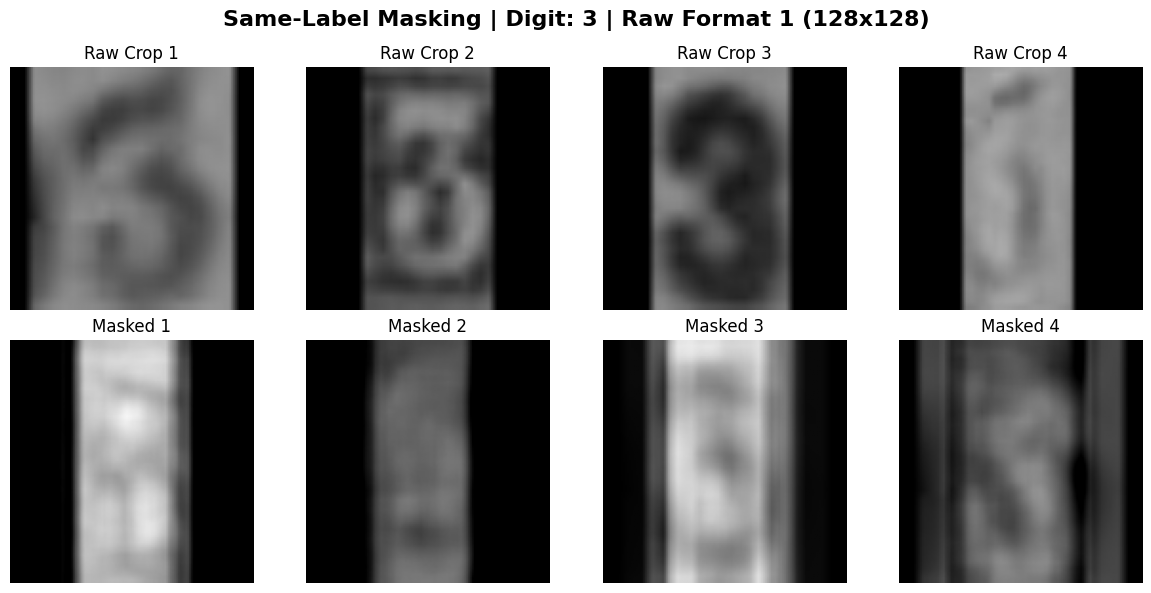

77

In [ ]:
print("\n=====================================================================")
print("VISUALIZING MATRIX MASKING ENCRYPTION (SVHN 128x128)")
print("=====================================================================")

labels_arr = train_dataset_full.labels.numpy()
unique_classes = np.unique(labels_arr)
random_class = random.choice(unique_classes)

class_indices = (labels_arr == random_class).nonzero()[0]
selected_indices = np.random.choice(class_indices, size=16, replace=False)

X_viz = torch.stack([train_dataset_full[i][0] for i in selected_indices]).to(device)
Y_viz = torch.tensor([train_dataset_full[i][1] for i in selected_indices]).to(device)

A_viz = generate_row_mask_gpu(Y_viz, 16, device)
X_viz_masked = A_viz @ X_viz

def unnormalize(tensor):
    return (tensor * 0.5) + 0.5

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle(f"Same-Label Masking | Digit: {random_class} | Raw Format 1 (128x128)", fontsize=16, fontweight='bold')

for i in range(4):
    ax_orig = axes[0, i]
    img_orig = unnormalize(X_viz[i]).view(IMAGE_SIZE, IMAGE_SIZE).cpu().numpy()
    ax_orig.imshow(img_orig, cmap='gray', vmin=0, vmax=1)
    ax_orig.set_title(f"Raw Crop {i+1}")
    ax_orig.axis('off')

    ax_mask = axes[1, i]
    img_mask = unnormalize(X_viz_masked[i]).view(IMAGE_SIZE, IMAGE_SIZE).cpu().numpy()
    ax_mask.imshow(img_mask, cmap='gray', vmin=0, vmax=1)
    ax_mask.set_title(f"Masked {i+1}")
    ax_mask.axis('off')

plt.tight_layout()
plt.show()

del X_viz, Y_viz, A_viz, X_viz_masked
torch.cuda.empty_cache()
gc.collect()

## 3. Evaluation Code & Model Architecture
To ensure complete transparency and allow researchers to build upon our work, we define the exact evaluation loop and model architecture used.

**Evaluation Function (`eval_model_loss_acc`):**
A robust, memory-efficient validation loop using PyTorch Mixed Precision to evaluate both accuracy and CrossEntropyLoss across validation/test loaders.

**Architecture (`DenseNet-121`):**
We utilize `DenseNet-121` initialized with default weights. Because we scaled the SVHN crops up to 128x128, the default 7x7 stride-2 convolution (`conv0`) and pooling layers are maintained. We only modify the input channel to accept 1-channel Grayscale images instead of RGB.

In [ ]:
# =====================================================================
# 0. HELPER FUNCTION: VALIDATION EVALUATOR
# =====================================================================
def eval_model_loss_acc(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for X_b, Y_b in loader:
            X_b = X_b.view(-1, 1, IMAGE_SIZE, IMAGE_SIZE).to(device)
            Y_b = Y_b.long().to(device)

            with torch.autocast(device_type='cuda', dtype=torch.float16):
                outputs = model(X_b)
                loss = criterion(outputs, Y_b)

            running_loss += loss.item() * X_b.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == Y_b).sum().item()
            total += Y_b.size(0)

            del X_b, Y_b, outputs, loss
    return running_loss / total, correct / total

def get_model(model_name, num_classes):
    if model_name == 'DenseNet-121':
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT, memory_efficient=True)
        # Because we scaled up to 128x128, the default DenseNet kernel (7x7) and pooling work perfectly.
        # We only need to adjust the input channels to 1 (Grayscale).
        old_conv = model.features.conv0
        model.features.conv0 = nn.Conv2d(1, old_conv.out_channels, kernel_size=old_conv.kernel_size,
                                       stride=old_conv.stride, padding=old_conv.padding, bias=old_conv.bias)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

    return model.to(device)

## 4. Training Code: Cloud Phase & Hospital Domain Adaptation
This section contains the core training scripts used to obtain the principal results stated in the paper. Running this cell will reproduce the overhead and accuracy metrics detailed in the SVHN results tables.

**Training Procedure & Hyperparameters:**
1.  **Cloud Phase:** Heavy training on the encrypted, statically masked data. We use the Adam optimizer (`lr=0.0008`), a maximum of 200 epochs, and a high patience early stopping criteria. To maximize cloud VRAM, we use a massive effective batch size of 4096. Hardware acceleration (Mixed Precision via `torch.amp.GradScaler`) is actively used.
2.  **Hospital Phase (Domain Adaptation):** Following the "Figshare Logic," we simulate the local hospital unfreezing a minimal subset of weights (`BatchNorm` layers, `denseblock4`, `norm5`, and the final `classifier`).
3.  **VRAM Scaling:** The hospital utilizes a batch size of 512. The learning rate is linearly scaled to `0.0002` (with `ReduceLROnPlateau`) to compensate for the adjusted batch distribution.

In [ ]:
print("\n=====================================================================")
print("THE FIGSHARE LOGIC: MAX CLOUD VRAM -> ULTRA-LOW LOCAL VRAM")
print("=====================================================================")

num_cloud_train = len(train_masked_ds)
cloud_val_size = int(0.20 * num_cloud_train)
cloud_train_size = num_cloud_train - cloud_val_size

generator = torch.Generator().manual_seed(42)
cloud_train_sub, cloud_val_sub = random_split(train_masked_ds, [cloud_train_size, cloud_val_size], generator=generator)

# CLOUD VRAM MAXIMIZER: Target 4096 effective batch.
CLOUD_TARGET_BATCH = 4096
CLOUD_ACCUM_STEPS = 1
CLOUD_MICRO_BATCH = CLOUD_TARGET_BATCH // CLOUD_ACCUM_STEPS

cloud_train_loader = DataLoader(cloud_train_sub, batch_size=CLOUD_MICRO_BATCH, shuffle=True, num_workers=2, pin_memory=True)

# VRAM LEAK FIX: Validation loaders locked to 256 to prevent out-of-memory spikes during evaluation
cloud_val_loader = DataLoader(cloud_val_sub, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
test_loader_masked = DataLoader(test_masked_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
test_loader_raw = DataLoader(test_dataset_full, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

cloud_model = get_model('DenseNet-121', num_classes=num_classes)
criterion = nn.CrossEntropyLoss()

# LINEAR LR SCALING: Adjusted to compensate for the massive 4096 batch size
optimizer_cloud = optim.Adam(cloud_model.parameters(), lr=0.0008)

# =====================================================================
# 2. CLOUD PHASE: Heavy Resource Usage
# =====================================================================
CLOUD_MAX_EPOCHS = 200
patience = 40
min_delta = 0.001
epochs_no_improve = 0
best_cloud_loss = float('inf')
best_cloud_weights = None
cloud_epochs_run = 0

print(f"1. CLOUD PHASE: Heavy VRAM Training on 128x128 Masked Data...")

torch.cuda.reset_peak_memory_stats()
start_time_cloud = time.time()
scaler = torch.amp.GradScaler('cuda')

for epoch in range(1, CLOUD_MAX_EPOCHS + 1):
    cloud_epochs_run += 1
    cloud_model.train()
    optimizer_cloud.zero_grad(set_to_none=True)

    for i, (X_b, Y_b) in enumerate(cloud_train_loader):
        X_b = X_b.view(-1, 1, IMAGE_SIZE, IMAGE_SIZE).to(device)
        Y_b = Y_b.long().to(device)

        with torch.autocast(device_type='cuda', dtype=torch.float16):
            outputs = cloud_model(X_b)
            loss = criterion(outputs, Y_b)
            loss = loss / CLOUD_ACCUM_STEPS

        scaler.scale(loss).backward()

        if (i + 1) % CLOUD_ACCUM_STEPS == 0 or (i + 1) == len(cloud_train_loader):
            scaler.step(optimizer_cloud)
            scaler.update()
            optimizer_cloud.zero_grad(set_to_none=True)

        del X_b, Y_b, outputs, loss

    val_loss, val_acc = eval_model_loss_acc(cloud_model, cloud_val_loader, criterion)

    print(f"   Epoch {epoch:>3} | Masked Val Loss: {val_loss:.4f} | Masked Acc: {val_acc:.4f} | Patience: {epochs_no_improve}/{patience}")

    if val_loss < (best_cloud_loss - min_delta):
        best_cloud_loss = val_loss
        best_cloud_weights = copy.deepcopy(cloud_model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"   -> Early Stopping Triggered! Restoring best Cloud weights.")
        break

if best_cloud_weights:
    cloud_model.load_state_dict(best_cloud_weights)

cloud_time = time.time() - start_time_cloud
cloud_memory = torch.cuda.max_memory_allocated() / (1024 ** 2)

print("\n=====================================================================")
print("PRE-TRANSFER EVALUATION: CLOUD MODEL ON VAULT DATA")
print("=====================================================================")
cloud_vault_masked_loss, cloud_vault_masked_acc = eval_model_loss_acc(cloud_model, test_loader_masked, criterion)
cloud_vault_raw_loss, cloud_vault_raw_acc = eval_model_loss_acc(cloud_model, test_loader_raw, criterion)
print(f"[CLOUD VAULT BASELINE] Masked Acc: {cloud_vault_masked_acc:.4f} | Raw Acc: {cloud_vault_raw_acc:.4f}\n")

# =====================================================================
# 3. HOSPITAL PHASE: Increased VRAM Utilization
# =====================================================================
print("3. HOSPITAL PHASE: Partial Unfreeze + High VRAM Utilization...")

num_full_raw = len(train_dataset_full)
# DATA REDUCTION: Reduced from 20% to 15% to speed up transfer learning
num_local_images = int(num_full_raw * 1)
samples_per_class = num_local_images // num_classes

targets = train_dataset_full.labels.numpy()
local_indices = []
np.random.seed(42)

for c in range(num_classes):
    class_idx = np.where(targets == c)[0]
    safe_samples = min(samples_per_class, len(class_idx))
    chosen = np.random.choice(class_idx, safe_samples, replace=False)
    local_indices.extend(chosen)

local_indices = np.array(local_indices)
np.random.shuffle(local_indices)

local_raw_pool = Subset(train_dataset_full, local_indices)
num_hosp_train = len(local_raw_pool)
hosp_val_size = int(0.20 * num_hosp_train)
hosp_train_size = num_hosp_train - hosp_val_size

hosp_raw_train, hosp_raw_val = random_split(local_raw_pool, [hosp_train_size, hosp_val_size], generator=generator)

# LOCAL VRAM INCREASE: Utilizing more GPU memory with a larger batch
TARGET_EFFECTIVE_BATCH = 512
ACCUMULATION_STEPS = 1
MICRO_BATCH_SIZE = max(1, TARGET_EFFECTIVE_BATCH // ACCUMULATION_STEPS) # Loads 512 images at once -> Higher VRAM

hosp_raw_loader = DataLoader(hosp_raw_train, batch_size=MICRO_BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
# Validation locked to 256 for memory safety
hosp_val_loader = DataLoader(hosp_raw_val, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

hosp_augmentations = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(degrees=10, translate=(0.05, 0.05))
])

hospital_model = copy.deepcopy(cloud_model)

# --- FIGSHARE LOGIC: PARTIAL UNFREEZE ---
for param in hospital_model.parameters():
    param.requires_grad = False

for module in hospital_model.modules():
    if isinstance(module, nn.BatchNorm2d):
        for param in module.parameters(): param.requires_grad = True

for param in hospital_model.features.denseblock4.parameters():
    param.requires_grad = True
for param in hospital_model.features.norm5.parameters():
    param.requires_grad = True
for param in hospital_model.classifier.parameters():
    param.requires_grad = True

params_to_update = [param for param in hospital_model.parameters() if param.requires_grad]

# LINEAR LR SCALING: Adjusted from 5e-5 to 0.0002 to compensate for the batch size of 512
optimizer_hospital = optim.Adam(params_to_update, lr=0.0002, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_hospital, mode='min', factor=0.5, patience=3, min_lr=1e-7)

HOSPITAL_MAX_EPOCHS = 50
hosp_patience = 8
hosp_no_improve = 0
best_hosp_loss = float('inf')
best_hospital_weights = None
hospital_epochs_run = 0

torch.cuda.reset_peak_memory_stats()
start_time_hospital = time.time()

for epoch in range(1, HOSPITAL_MAX_EPOCHS + 1):
    hospital_epochs_run += 1
    hospital_model.train()
    optimizer_hospital.zero_grad(set_to_none=True)

    for i, (X_b, Y_b) in enumerate(hosp_raw_loader):
        X_b = X_b.view(-1, 1, IMAGE_SIZE, IMAGE_SIZE).to(device)
        X_b = hosp_augmentations(X_b)
        Y_b = Y_b.long().to(device)

        with torch.autocast(device_type='cuda', dtype=torch.float16):
            outputs = hospital_model(X_b)
            loss = criterion(outputs, Y_b)
            loss = loss / ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        if (i + 1) % ACCUMULATION_STEPS == 0 or (i + 1) == len(hosp_raw_loader):
            scaler.unscale_(optimizer_hospital)
            torch.nn.utils.clip_grad_norm_(hospital_model.parameters(), max_norm=1.0)

            scaler.step(optimizer_hospital)
            scaler.update()

            optimizer_hospital.zero_grad(set_to_none=True)

        del X_b, Y_b, outputs, loss

    raw_val_loss, raw_val_acc = eval_model_loss_acc(hospital_model, hosp_val_loader, criterion)
    _, masked_test_acc = eval_model_loss_acc(hospital_model, test_loader_masked, criterion)

    current_lr = optimizer_hospital.param_groups[0]['lr']
    scheduler.step(raw_val_loss)

    print(f"   Epoch {epoch:>2} | Raw Val Loss: {raw_val_loss:.4f} | Masked Acc: {masked_test_acc:.4f} | Raw Acc: {raw_val_acc:.4f} | LR: {current_lr:.1e} | Patience: {hosp_no_improve}/{hosp_patience}")

    if raw_val_loss < (best_hosp_loss - min_delta):
        best_hosp_loss = raw_val_loss
        best_hospital_weights = copy.deepcopy(hospital_model.state_dict())
        hosp_no_improve = 0
    else:
        hosp_no_improve += 1

    if hosp_no_improve >= hosp_patience:
        print(f"   -> Early Stopping Triggered! Restoring best Local weights.")
        break

if best_hospital_weights:
    hospital_model.load_state_dict(best_hospital_weights)

hospital_time = time.time() - start_time_hospital
hospital_memory = torch.cuda.max_memory_allocated() / (1024 ** 2)

# =====================================================================
# 4. OPENING THE VAULT: FINAL UNBIASED EVALUATION
# =====================================================================
print("\n=====================================================================")
print("POST-TRANSFER EVALUATION: HOSPITAL MODEL ON VAULT DATA")
print("=====================================================================")
print("\n--> TRANSFER LEARNING OVERHEAD COST:")
print(f"    Data Volume: Cloud used {cloud_train_size} train imgs | Hospital used {hosp_train_size} augmented raw imgs")
print(f"    Cloud Training Took: {cloud_epochs_run} epochs ({cloud_time:.2f} sec, {cloud_memory:.2f} MB)")
print(f"    Hospital Tuning Took: {hospital_epochs_run} epochs ({hospital_time:.2f} sec, {hospital_memory:.2f} MB)")

final_masked_loss, final_masked_acc = eval_model_loss_acc(hospital_model, test_loader_masked, criterion)
final_raw_loss, final_raw_acc = eval_model_loss_acc(hospital_model, test_loader_raw, criterion)

print(f"\n[HOSPITAL VAULT TEST] Final Masked Acc: {final_masked_acc:.4f} | Final Raw Acc: {final_raw_acc:.4f}\n")


THE FIGSHARE LOGIC: MAX CLOUD VRAM -> ULTRA-LOW LOCAL VRAM
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 316MB/s]

1. CLOUD PHASE: Heavy VRAM Training on 128x128 Masked Data...


   Epoch   1 | Masked Val Loss: 5.6595 | Masked Acc: 0.1625 | Patience: 0/40
   Epoch   2 | Masked Val Loss: 5.6484 | Masked Acc: 0.1805 | Patience: 0/40
   Epoch   3 | Masked Val Loss: 3.9512 | Masked Acc: 0.3435 | Patience: 0/40
   Epoch   4 | Masked Val Loss: 1.0851 | Masked Acc: 0.7303 | Patience: 0/40
   Epoch   5 | Masked Val Loss: 0.0876 | Masked Acc: 0.9718 | Patience: 0/40
   Epoch   6 | Masked Val Loss: 0.0293 | Masked Acc: 0.9920 | Patience: 0/40
   Epoch   7 | Masked Val Loss: 0.0165 | Masked Acc: 0.9953 | Patience: 0/40
   Epoch   8 | Masked Val Loss: 0.0083 | Masked Acc: 0.9980 | Patience: 0/40
   Epoch   9 | Masked Val Loss: 0.0379 | Masked Acc: 0.9911 | Patience: 0/40
   Epoch  10 | Masked Val Loss: 0.0087 | Masked Acc: 0.9975 | Patience: 1/40
   Epoch  11 | Masked Val Loss: 0.0141 | Masked Acc: 0.9962 | Patience: 2/40
   Epoch  12 | Masked Val Loss: 0.0067 | Masked Acc: 0.9976 | Patience: 3/40
   Epoch  13 | Masked Val Loss: 0.0068 | Masked Acc: 0.9983 | Patience: 0/40